In [1]:
# Paso 1: importar librerias

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Ignorar warnings
# ==============================================================================
import warnings
warnings.filterwarnings("ignore")

plt.style.use("default")

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

In [2]:
# Paso 1: cargar dataset final

def cargar_dataset(ruta):
    """
    Carga el dataset final generado durante el proceso
    de Feature Engineering.

    Parametros
    ----------
    ruta : str o Path
        Ruta del archivo pickle.

    Devuelve
    --------
    pd.DataFrame
        Dataset final listo para análisis.
    """
    return pd.read_pickle(ruta)


df = cargar_dataset("../data/processed/ecommerce_brazil_final.pkl")

df.shape

(99441, 51)

In [3]:
# Paso 2: calcular KPIs generales

def obtener_kpis_generales(df):
    """
    Calcula los principales KPIs del negocio.
    """

    return pd.Series({
        "Pedidos": df["order_id"].nunique(),
        "Clientes": df["customer_unique_id"].nunique(),
        "Ventas Totales": round(df["order_total_value"].sum(), 2),
        "Ticket Medio": round(df["order_total_value"].mean(), 2),
        "Pedidos Entregados (%)": round(df["is_delivered"].mean() * 100, 2),
        "Pedidos Retrasados (%)": round(df["is_late"].mean() * 100, 2),
        "Pedidos en Festivo (%)": round(df["is_holiday"].mean() * 100, 2),
        "Coste Medio Envío": round(df["order_freight_value"].mean(), 2)
    })

obtener_kpis_generales(df)

Pedidos                      99441.00
Clientes                     96096.00
Ventas Totales            15843553.24
Ticket Medio                   160.58
Pedidos Entregados (%)          97.02
Pedidos Retrasados (%)           7.87
Pedidos en Festivo (%)           2.72
Coste Medio Envío               22.82
dtype: float64

In [4]:
# Paso 3: pedidos por mes

def pedidos_por_mes(df):
    """
    Calcula el número de pedidos por mes.

    Parametros
    ----------
    df : pd.DataFrame

    Devuelve
    --------
    pd.DataFrame
    """
    resultado = (
        df.groupby(
            pd.Grouper(
                key="order_purchase_date",
                freq="M"
            )
        )["order_id"]
        .count()
        .reset_index()
    )

    return resultado

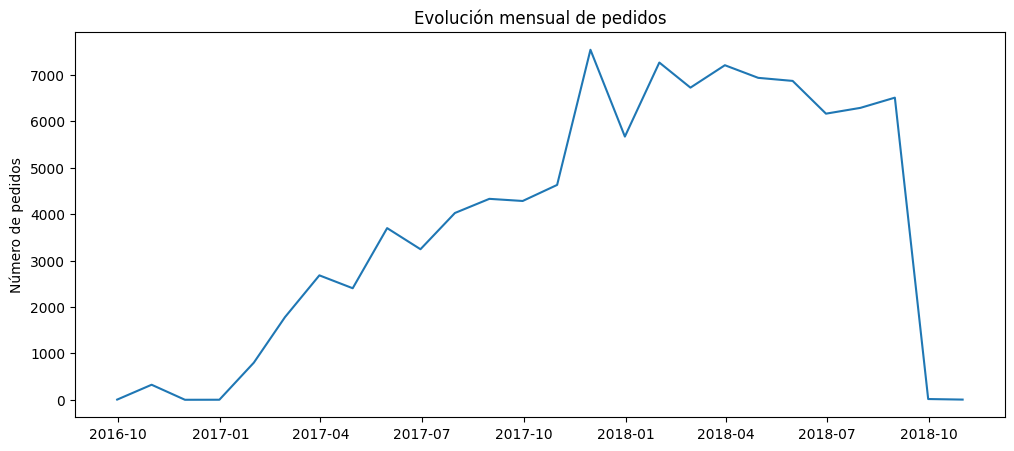

In [5]:
# Paso 3.1: visualización de pedidos por mes
 
pedidos_mes = pedidos_por_mes(df)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=pedidos_mes,
    x="order_purchase_date",
    y="order_id"
)

plt.title("Evolución mensual de pedidos")
plt.xlabel("")
plt.ylabel("Número de pedidos")

plt.show()

In [6]:
# Paso 4: pedidos por día de la semana

dias = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo"
}

pedidos_dia = (
    df["purchase_dayofweek"]
    .map(dias)
    .value_counts()
)

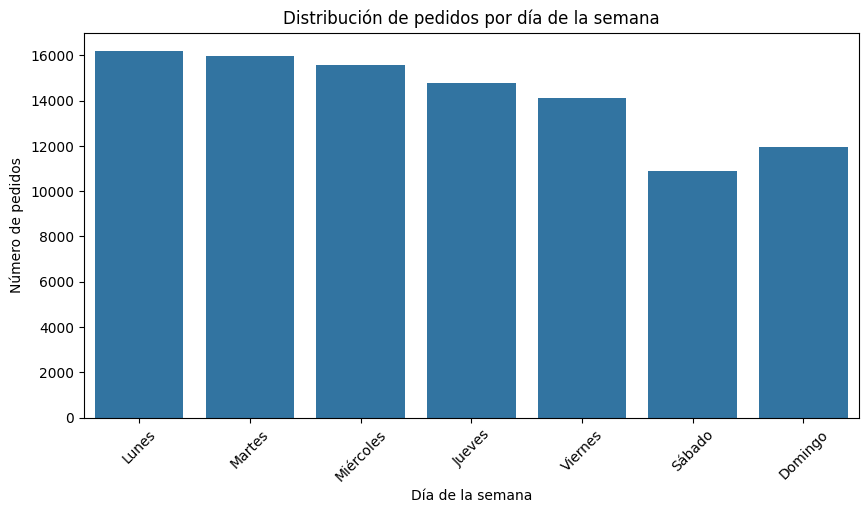

In [7]:
# Paso 4.1: visualizar pedidos por día de la semana

orden_dias = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

pedidos_dia = pedidos_dia.reindex(orden_dias)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=pedidos_dia.index,
    y=pedidos_dia.values
)

plt.title("Distribución de pedidos por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Número de pedidos")
plt.xticks(rotation=45)

plt.show()

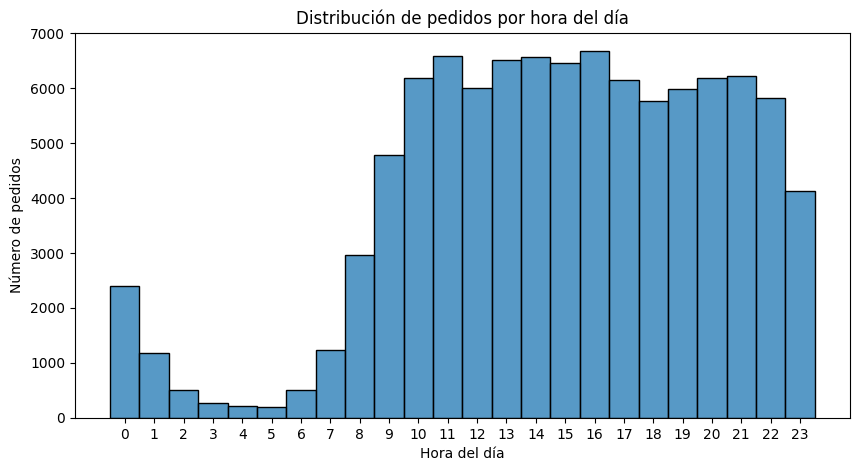

In [8]:
# Paso 4.2: distribución horaria

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="purchase_hour",
    bins=24,
    discrete=True
)

plt.title("Distribución de pedidos por hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Número de pedidos")

plt.xticks(range(24))

plt.show()

In [9]:
# Paso 5: distribución de estados
 
def analizar_estado_pedidos(df):
    """
    Calcula la distribución porcentual de los estados de pedido.

    Parámetros
    ----------
    df : pd.DataFrame
        Dataset final del proyecto.

    Devuelve
    --------
    pd.DataFrame
        Tabla con el porcentaje de pedidos por estado.
    """

    resultado = (
        df["order_status"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .reset_index()
    )

    resultado.columns = [
        "order_status",
        "porcentaje"
    ]

    return resultado

estado_pedidos = analizar_estado_pedidos(df)

estado_pedidos


,order_status,porcentaje
0,delivered,97.02
1,shipped,1.11
2,canceled,0.63
3,unavailable,0.61
4,invoiced,0.32
5,processing,0.30
6,created,0.01
7,approved,0.00


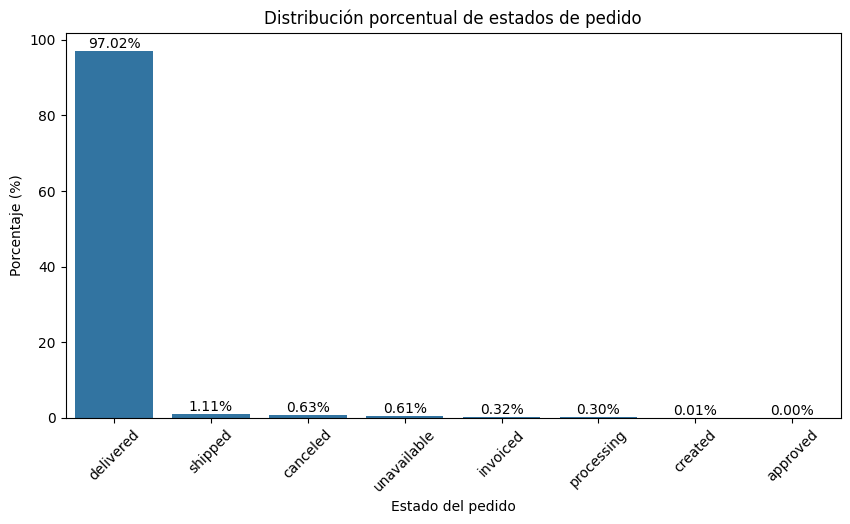

In [10]:
# Paso 5.1: visualización de la distribución de estados
 
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=estado_pedidos,
    x="order_status",
    y="porcentaje"
)

for barra in ax.patches:
    ax.annotate(
        f"{barra.get_height():.2f}%",
        (
            barra.get_x() + barra.get_width() / 2,
            barra.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.title(
    "Distribución porcentual de estados de pedido"
)

plt.xlabel("Estado del pedido")
plt.ylabel("Porcentaje (%)")

plt.xticks(rotation=45)

plt.show()

In [11]:
# Paso 6: top categorías por ventas

def obtener_top_categorias_ventas(df, top_n=10):
    """
    Calcula las categorías que generan mayor volumen de ventas.

    Parámetros
    ----------
    df : pd.DataFrame
        Dataset final del proyecto.

    top_n : int, default=10
        Número de categorías a mostrar.

    Devuelve
    --------
    pd.DataFrame
        Categorías ordenadas por ventas descendentes.
    """

    resultado = (
        df.groupby("main_product_category", dropna=True)
        ["order_total_value"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )

    return resultado


top_categorias = obtener_top_categorias_ventas(df)

top_categorias

,main_product_category,order_total_value
0,health_beauty,1442304.33
1,watches_gifts,1306537.36
2,bed_bath_table,1249303.58
3,sports_leisure,1155900.55
4,computers_accessories,1060955.93
5,furniture_decor,899725.68
6,housewares,777678.89
7,cool_stuff,719415.50
8,auto,685521.51
9,garden_tools,582502.83


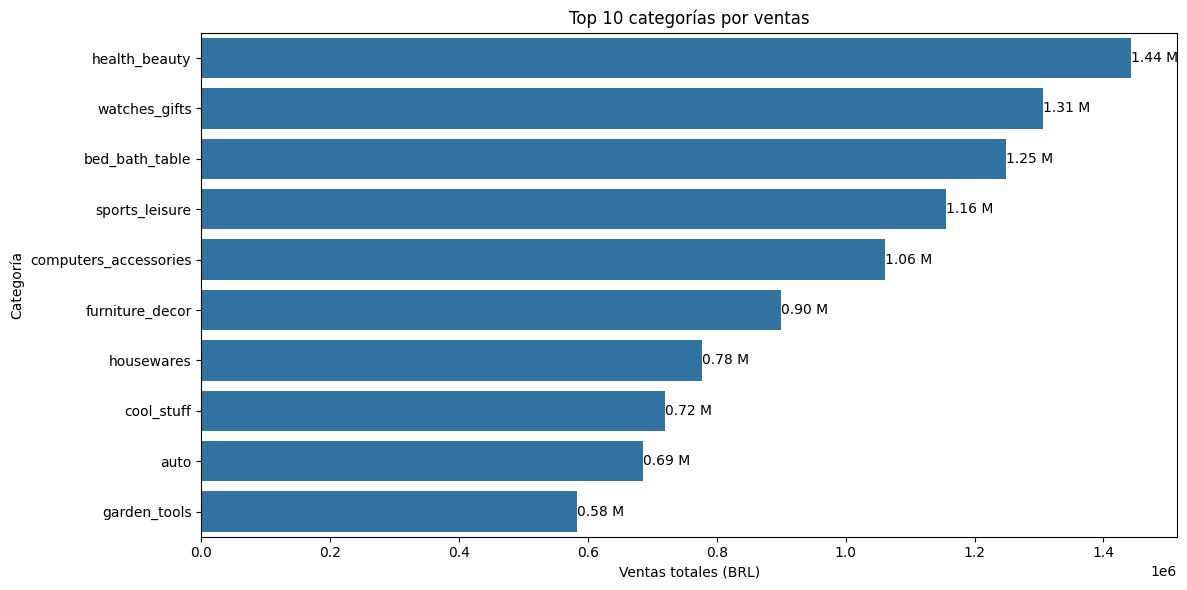

In [12]:
# Paso 6.1: gráfico top categorías por ventas

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=top_categorias,
    x="order_total_value",
    y="main_product_category"
)

for barra in ax.patches:

    valor = barra.get_width()

    ax.annotate(
        f"{valor/1_000_000:.2f} M",
        (
            valor,
            barra.get_y() + barra.get_height()/2
        ),
        va="center"
    )

plt.title(
    "Top 10 categorías por ventas"
)
plt.xlabel("Ventas totales (BRL)")
plt.ylabel("Categoría")

plt.tight_layout()

plt.show()

In [13]:
# Paso 7: distribución de métodos de pago

def obtener_distribucion_metodos_pago(df):
    """
    Calcula la distribución porcentual de los métodos de pago.

    Parámetros
    ----------
    df : pd.DataFrame
        Dataset final del proyecto.

    Devuelve
    --------
    pd.DataFrame
        Tabla con el porcentaje de pedidos por método de pago.
    """

    resultado = (
        df["payment_type_main"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .reset_index()
    )

    resultado.columns = [
        "payment_type",
        "percentage"
    ]

    return resultado


metodos_pago = obtener_distribucion_metodos_pago(df)

metodos_pago

,payment_type,percentage
0,credit_card,76.56
1,boleto,19.90
2,voucher,2.01
3,debit_card,1.54
4,not_defined,0.00


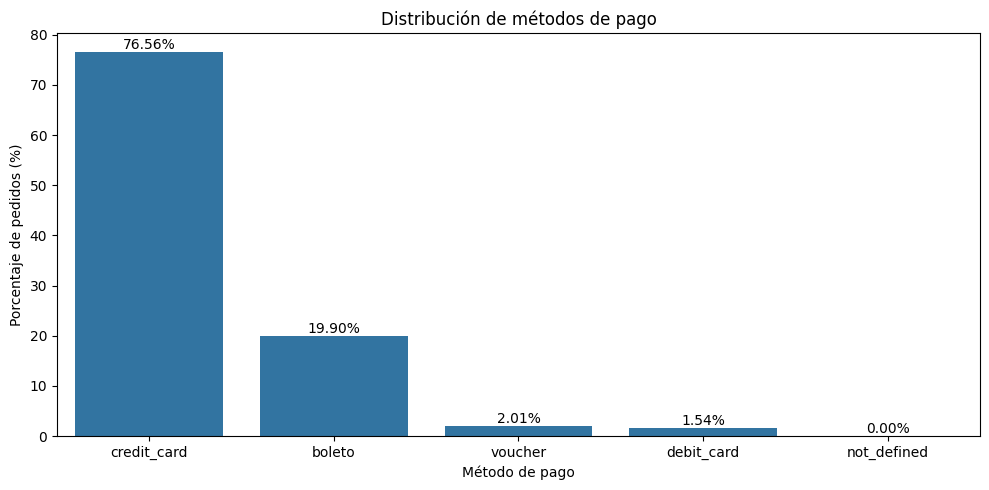

In [14]:
# Paso 7.1: gráfico métodos de pago

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=metodos_pago,
    x="payment_type",
    y="percentage"
)

for barra in ax.patches:
    ax.annotate(
        f"{barra.get_height():.2f}%",
        (
            barra.get_x() + barra.get_width() / 2,
            barra.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.title(
    "Distribución de métodos de pago"
)

plt.xlabel("Método de pago")
plt.ylabel("Porcentaje de pedidos (%)")

plt.tight_layout()

plt.show()

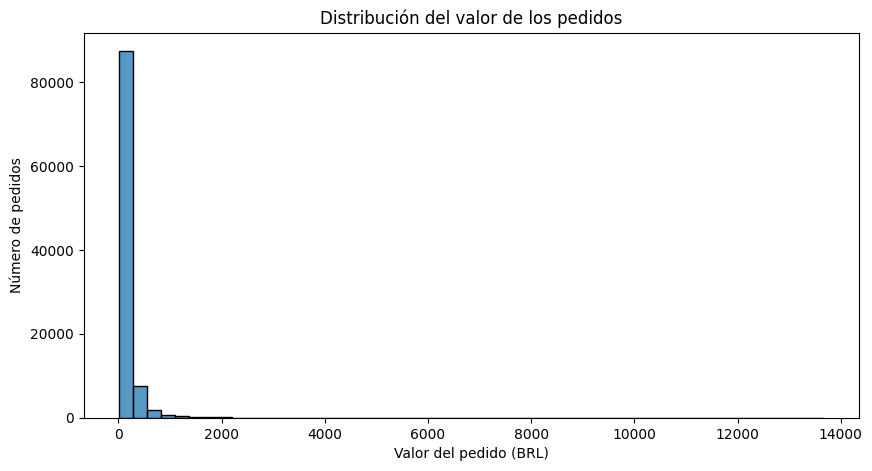

In [15]:
# Paso 8. Distribución del valor económico de los pedidos

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="order_total_value",
    bins=50
)

plt.title(
    "Distribución del valor de los pedidos"
)

plt.xlabel("Valor del pedido (BRL)")
plt.ylabel("Número de pedidos")

plt.show()

In [16]:
# Paso 8.1 Segmentación de pedidos por valor económico
 
segmentos = (
    df["order_value_segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

segmentos.columns = [
    "segmento",
    "porcentaje"
]

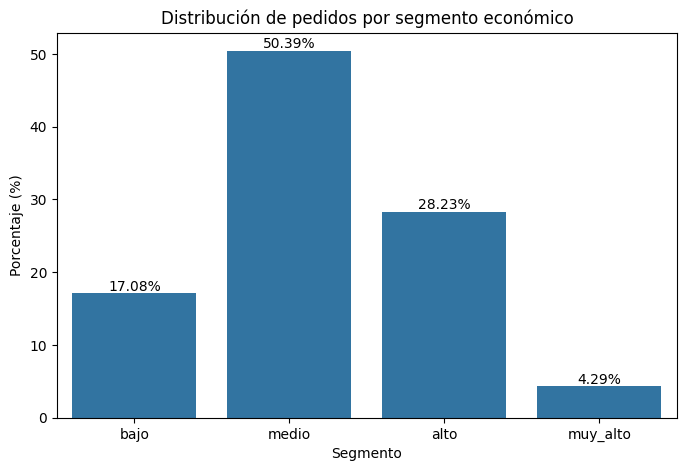

In [17]:
# Paso 8.2 Gráficos de segmentos
 
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=segmentos,
    x="segmento",
    y="porcentaje"
)

for barra in ax.patches:
    ax.annotate(
        f"{barra.get_height():.2f}%",
        (
            barra.get_x() + barra.get_width()/2,
            barra.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.title(
    "Distribución de pedidos por segmento económico"
)

plt.xlabel("Segmento")
plt.ylabel("Porcentaje (%)")

plt.show()

In [18]:
# Paso 9: distribución de artículos por pedido

def obtener_distribucion_articulos(df):
    """
    Calcula la distribución del número de artículos
    incluidos en cada pedido.

    Parámetros
    ----------
    df : pd.DataFrame
        Dataset final del proyecto.

    Devuelve
    --------
    pd.Series
        Frecuencia de pedidos por número de artículos.
    """

    return (
        df["total_items"]
        .dropna()
        .astype(int)
        .value_counts()
        .sort_index()
    )

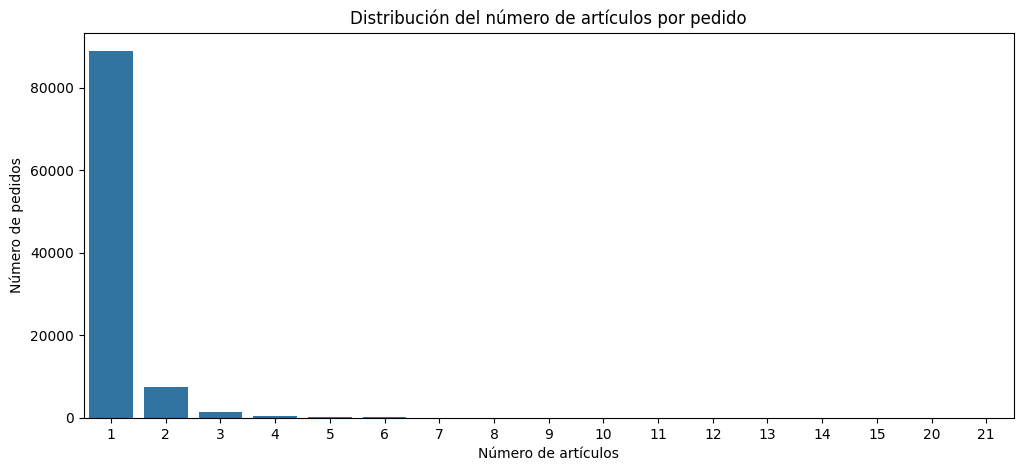

In [19]:
# Paso 9.1: gráfico número de artículos por pedido

articulos_pedido = obtener_distribucion_articulos(df)

plt.figure(figsize=(12, 5))

ax = sns.barplot(
    x=articulos_pedido.index,
    y=articulos_pedido.values
)

plt.title(
    "Distribución del número de artículos por pedido"
)

plt.xlabel("Número de artículos")
plt.ylabel("Número de pedidos")

plt.show()

In [20]:
# Paso 9.2: distribución segmentos de artículos por pedido
 
segmentos_items = (
    df["items_segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

segmentos_items.columns = [
    "segmento",
    "porcentaje"
]

segmentos_items

,segmento,porcentaje
0,un_producto,90.06
1,dos_tres_productos,8.96
2,mas_de_tres_productos,0.98


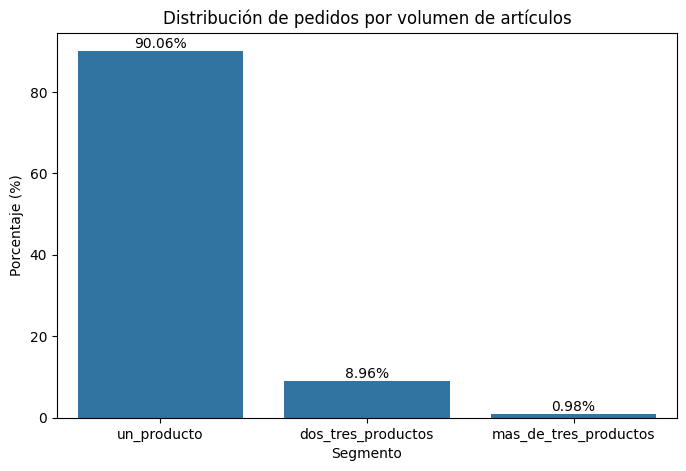

In [21]:
# Paso 9.3: gráfico segmentos de artículos por pedido
 
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=segmentos_items,
    x="segmento",
    y="porcentaje"
)

for barra in ax.patches:
    ax.annotate(
        f"{barra.get_height():.2f}%",
        (
            barra.get_x() + barra.get_width()/2,
            barra.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.title(
    "Distribución de pedidos por volumen de artículos"
)

plt.xlabel("Segmento")
plt.ylabel("Porcentaje (%)")

plt.show()

In [22]:
# Paso 10. Distribución geográfica de los pedidos
 
def obtener_top_estados(df, top_n=10):
    """
    Calcula los estados con mayor volumen de pedidos.

    Parámetros
    ----------
    df : pd.DataFrame
        Dataset final.

    top_n : int, default=10
        Número de estados a mostrar.

    Devuelve
    --------
    pd.DataFrame
        Top estados por número de pedidos.
    """

    resultado = (
        df["customer_state"]
        .value_counts()
        .head(top_n)
        .reset_index()
    )

    resultado.columns = [
        "estado",
        "pedidos"
    ]

    return resultado


top_estados = obtener_top_estados(df)
top_estados

,estado,pedidos
0,sp,41746
1,rj,12852
2,mg,11635
3,rs,5466
4,pr,5045
5,sc,3637
6,ba,3380
7,df,2140
8,es,2033
9,go,2020


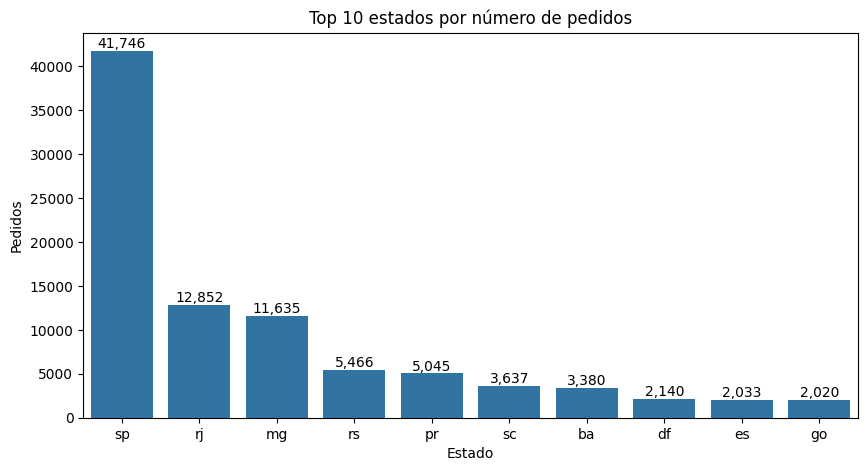

In [23]:
# Paso 10. Gráfico sobre la distribución geográfica de los pedidos
 
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=top_estados,
    x="estado",
    y="pedidos"
)

for barra in ax.patches:
    ax.annotate(
        f"{int(barra.get_height()):,}",
        (
            barra.get_x() + barra.get_width()/2,
            barra.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.title("Top 10 estados por número de pedidos")
plt.xlabel("Estado")
plt.ylabel("Pedidos")

plt.show()

In [24]:
# Paso 11. Evolución temporal de las ventas
 
ventas_mes = (
    df.groupby(
        pd.Grouper(
            key="order_purchase_date",
            freq="M"
        )
    )["order_total_value"]
    .sum()
    .reset_index()
)

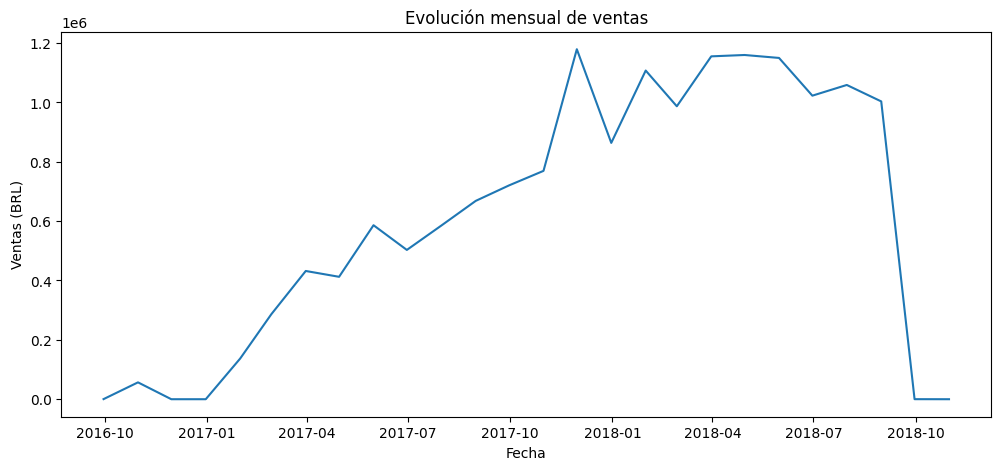

In [25]:
# Paso 11.1 Gráfico de evolución temporal de las ventas
 
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=ventas_mes,
    x="order_purchase_date",
    y="order_total_value"
)

plt.title("Evolución mensual de ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas (BRL)")

plt.show()

In [26]:
# Paso 12. Impacto de los festivos en las ventas
 
ventas_festivo = (
    df.groupby("is_holiday")
    ["order_total_value"]
    .mean()
    .reset_index()
)

ventas_festivo["is_holiday"] = (
    ventas_festivo["is_holiday"]
    .map({
        0: "No festivo",
        1: "Festivo"
    })
)

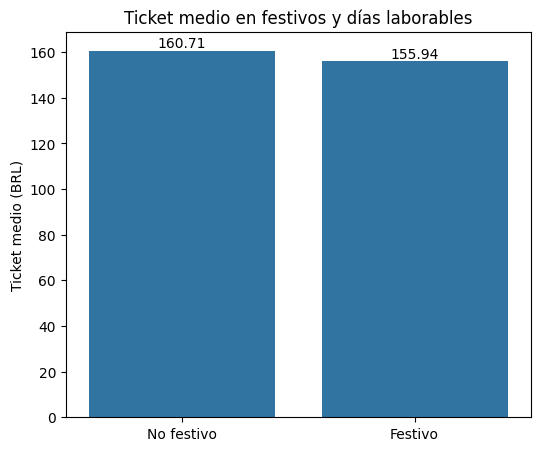

In [27]:
# Paso 12.1 Gráfico impacto de los festivos en las ventas
 
plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=ventas_festivo,
    x="is_holiday",
    y="order_total_value"
)

for barra in ax.patches:
    ax.annotate(
        f"{barra.get_height():.2f}",
        (
            barra.get_x() + barra.get_width()/2,
            barra.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.title(
    "Ticket medio en festivos y días laborables"
)

plt.xlabel("")
plt.ylabel("Ticket medio (BRL)")

plt.show()

In [28]:
# Paso 13. Rendimiento logístico: pedidos entregados a tiempo vs retrasados
 
retrasos = (
    df["is_late"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

retrasos.columns = [
    "estado",
    "porcentaje"
]

retrasos["estado"] = retrasos["estado"].map({
    0: "En plazo",
    1: "Retrasado"
})

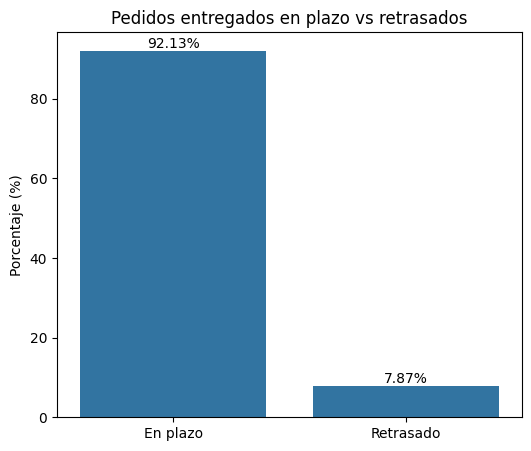

In [29]:
# Paso 13.1 Gráfico sobre rendimiento logístico: pedidos entregados a tiempo vs retrasados
 
plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=retrasos,
    x="estado",
    y="porcentaje"
)

for barra in ax.patches:
    ax.annotate(
        f"{barra.get_height():.2f}%",
        (
            barra.get_x() + barra.get_width()/2,
            barra.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.title(
    "Pedidos entregados en plazo vs retrasados"
)

plt.xlabel("")
plt.ylabel("Porcentaje (%)")

plt.show()

# Conclusiones del Análisis Exploratorio

## Visión general del negocio

El marketplace analizado registra un volumen de actividad considerable, con más de **99.000 pedidos**, **96.096 clientes únicos** y una facturación superior a **15,8 millones de BRL** durante el periodo estudiado.

El **ticket medio** se sitúa en **160,58 BRL**, lo que indica que la plataforma se sustenta principalmente en compras de valor intermedio y no en microtransacciones ni en productos de lujo de elevado importe.

Además, el negocio presenta una elevada estabilidad operativa, con un **97,02 % de pedidos entregados correctamente** y un **92,13 % de entregas realizadas dentro del plazo previsto**.

---

## Evolución y crecimiento del marketplace

El análisis temporal muestra una clara evolución positiva del negocio.

Durante 2017 se observa una fase de fuerte crecimiento tanto en el número de pedidos como en las ventas, mientras que en 2018 el marketplace alcanza una etapa de consolidación manteniendo niveles elevados de actividad.

La evolución de las ventas sigue un patrón muy similar al volumen de pedidos, lo que indica que el crecimiento del negocio está impulsado principalmente por el aumento de la demanda y no únicamente por incrementos en el valor medio de las compras.

---

## Comportamiento de compra de los clientes

Los clientes realizan sus compras principalmente durante los días laborables.

Los lunes, martes y miércoles concentran el mayor volumen de pedidos, mientras que la actividad disminuye progresivamente hacia el fin de semana, alcanzando su mínimo durante el sábado.

A nivel horario, las compras se concentran entre las **10:00 y las 22:00 horas**, con una actividad especialmente elevada entre media mañana y última hora de la tarde.

Este patrón sugiere que las compras responden a necesidades planificadas e integradas en la rutina diaria de los consumidores más que a comportamientos impulsivos asociados al ocio.

---

## Estructura económica de los pedidos

La distribución del valor de los pedidos presenta una marcada asimetría positiva, típica de los entornos de comercio electrónico.

La mayoría de las compras corresponden a importes bajos o medios, mientras que existe un pequeño grupo de pedidos de elevado valor que generan una cola larga en la distribución.

La segmentación económica confirma este comportamiento:

- **50,39 %** de los pedidos pertenecen al segmento medio.
- **28,23 %** pertenecen al segmento alto.
- Solo **4,29 %** corresponden al segmento muy alto.

En conjunto, más del **78 % de los pedidos** se sitúan en los segmentos medio y alto.

---

## Composición de los pedidos

Uno de los hallazgos más relevantes del análisis es la fuerte concentración de pedidos con un único producto.

El **90,06 % de las compras contienen un solo artículo**, mientras que menos del 10 % incluyen dos o más productos.

Este comportamiento indica que los clientes utilizan la plataforma principalmente para satisfacer necesidades concretas mediante compras puntuales, en lugar de realizar grandes cestas de productos.

Desde una perspectiva de negocio, este patrón podría representar una oportunidad para implementar estrategias de **cross-selling** y **up-selling** orientadas a incrementar el número medio de artículos por pedido.

---

## Categorías que impulsan las ventas

Las ventas se concentran en un conjunto reducido de categorías que actúan como principales motores de facturación.

Las categorías con mayor volumen de ventas son:

- Health & Beauty
- Watches & Gifts
- Bed Bath & Table
- Sports & Leisure
- Computers & Accessories

Estas categorías superan individualmente el millón de BRL en ventas acumuladas y muestran que el marketplace presenta una oferta diversificada, sin una dependencia excesiva de una única línea de negocio.

Los sectores relacionados con el hogar, la tecnología y el bienestar constituyen los principales generadores de ingresos de la plataforma.

---

## Métodos de pago

La tarjeta de crédito es el método de pago claramente predominante, representando el **76,56 % de los pedidos**.

El segundo método más utilizado es el **boleto**, con un **19,90 %**, mientras que el resto de opciones tienen una presencia residual.

Estos resultados reflejan una elevada adopción de medios de pago electrónicos y muestran una clara preferencia de los consumidores por la financiación mediante tarjeta de crédito.

---

## Distribución geográfica de la demanda

La actividad del marketplace presenta una importante concentración geográfica.

El estado de **São Paulo** lidera ampliamente el volumen de pedidos con más de **41.000 transacciones**, representando aproximadamente el **42 % del total**.

Junto con **Río de Janeiro** y **Minas Gerais**, concentra cerca de dos tercios de toda la actividad registrada.

Este comportamiento es coherente con la realidad económica y demográfica de Brasil, donde la región sudeste concentra gran parte de la población y de la actividad económica del país.

---

## Impacto de los festivos

La incorporación del calendario de festivos permitió analizar si existían diferencias significativas en el comportamiento de compra.

Los resultados muestran que los pedidos realizados en festivos representan únicamente el **2,72 % del total** y que el ticket medio es muy similar al observado en días no festivos.

Por tanto, los festivos no parecen ejercer una influencia relevante sobre el comportamiento general de compra de los clientes.

---

## Rendimiento logístico

El marketplace presenta un rendimiento logístico notablemente eficiente.

Los resultados muestran que:

- El **97,02 % de los pedidos** finalizan correctamente con estado entregado.
- El **92,13 % de las entregas** se realizan dentro del plazo previsto.
- Los pedidos cancelados o no disponibles representan una proporción muy reducida del total.

Estos indicadores reflejan una operación logística sólida y una experiencia de compra fiable para la mayoría de los clientes.

---

## Conclusión general

El análisis exploratorio permite concluir que Olist opera como un marketplace consolidado, con un elevado volumen de actividad, una fuerte concentración de clientes en la región sudeste de Brasil y un modelo de compra basado principalmente en pedidos individuales de valor medio.

El crecimiento sostenido observado durante el periodo analizado, unido a los altos niveles de cumplimiento logístico y a la estabilidad del comportamiento de compra, evidencian un negocio maduro y eficiente.

Los resultados también identifican oportunidades de mejora relacionadas con el aumento del número de artículos por pedido y la expansión de la actividad en regiones con menor presencia dentro de la plataforma.